In [35]:
#. GAURAV CHAUHAN
#  E23CSEU0554


import os
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

file_name = "heart_failure_clinical_records_dataset.csv"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [4]:
df = pd.read_csv(file_name)

print("First 5 rows:")
display(df.head())

First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 299
Number of columns: 13


In [6]:
print("Data types:")
print(df.dtypes)

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
display(df.describe())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


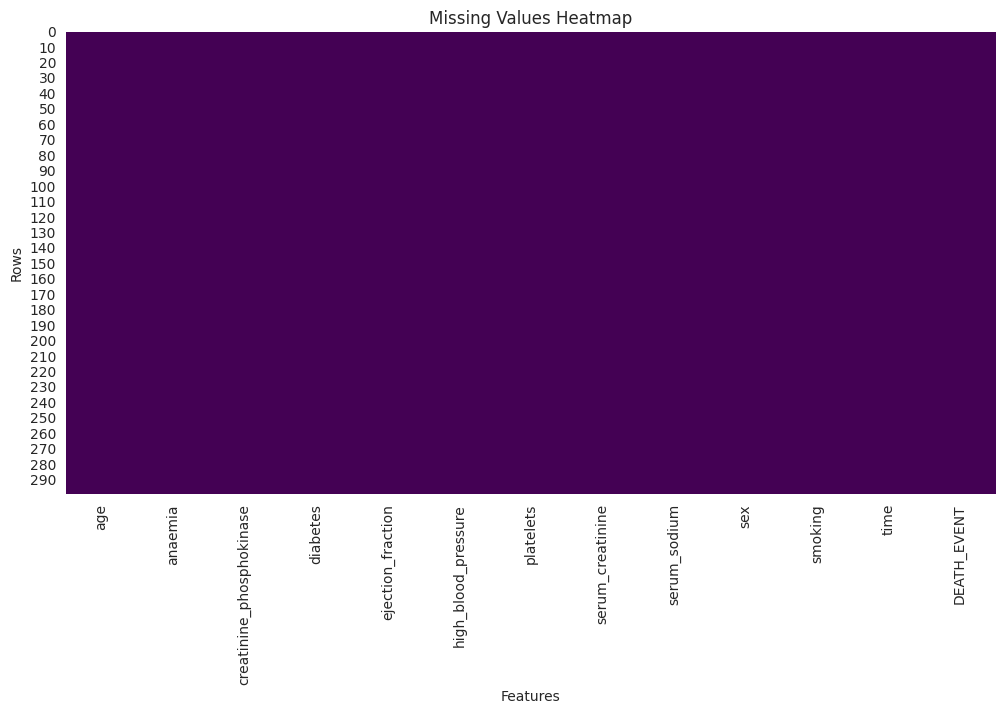

In [10]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Rows")
plt.show()

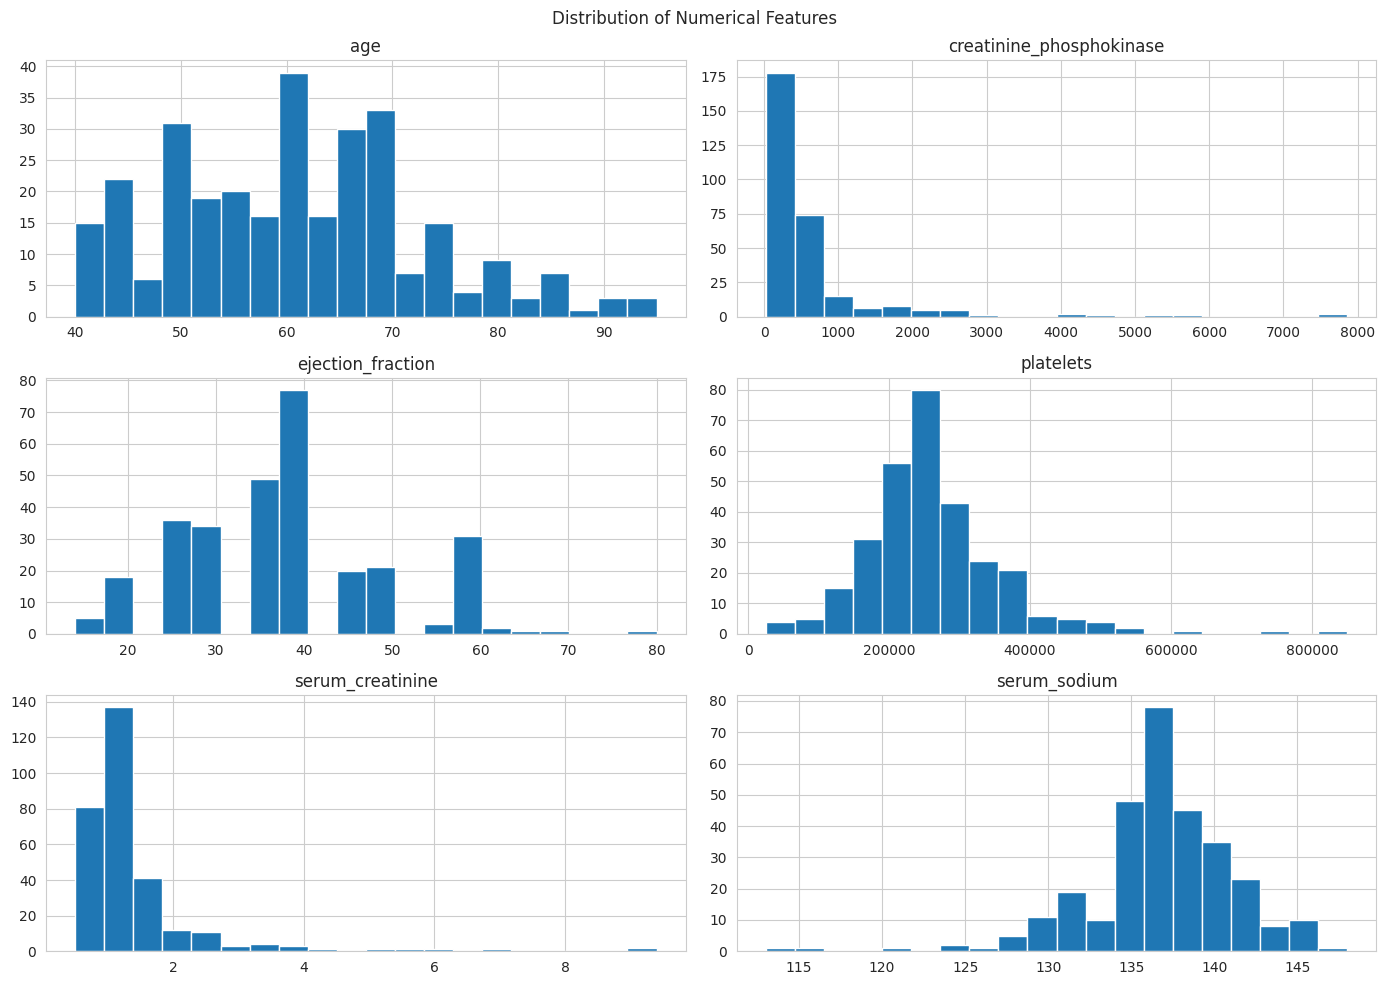

In [11]:
numerical_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

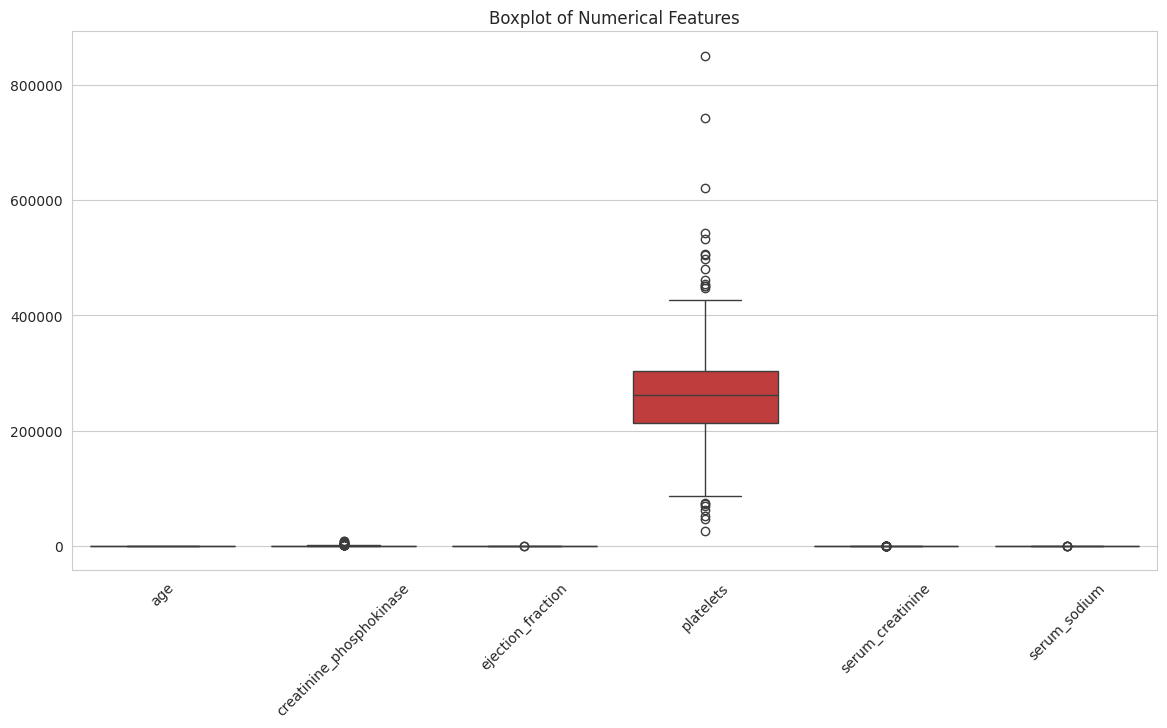

In [12]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=df[numerical_columns])

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

In [13]:
print("Minimum values:")
print(df[numerical_columns].min())

Minimum values:
age                            40.0
creatinine_phosphokinase       23.0
ejection_fraction              14.0
platelets                   25100.0
serum_creatinine                0.5
serum_sodium                  113.0
dtype: float64


In [14]:
# Age cannot be negative
df.loc[df["age"] < 0, "age"] = np.nan

# Medical measurements should not be negative
for col in [
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]:
    df.loc[df[col] < 0, col] = np.nan

print("Invalid values handled.")

Invalid values handled.


In [15]:
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

print("Numerical missing values filled using median.")

Numerical missing values filled using median.


In [16]:
categorical_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Categorical missing values filled using mode.")

Categorical missing values filled using mode.


In [17]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [18]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 299
Rows after removing duplicates: 299
Duplicates removed: 0


In [19]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Outliers removed using IQR method.")
print("Remaining rows:", len(df))

Outliers removed using IQR method.
Remaining rows: 224


In [20]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[-np.inf, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

display(df[["age", "age_group"]].head())

,age,age_group
0,75.0,>60
2,65.0,>60
3,50.0,40-60
5,90.0,>60
6,75.0,>60


In [21]:
ef_min = df["ejection_fraction"].min()
ef_max = df["ejection_fraction"].max()

creatinine_min = df["serum_creatinine"].min()
creatinine_max = df["serum_creatinine"].max()

df["ejection_fraction_norm"] = (
    (df["ejection_fraction"] - ef_min) /
    (ef_max - ef_min)
)

df["serum_creatinine_norm"] = (
    (df["serum_creatinine"] - creatinine_min) /
    (creatinine_max - creatinine_min)
)

In [22]:
df["risk_score"] = (
    (1 - df["ejection_fraction_norm"]) *
    df["serum_creatinine_norm"]
)

display(
    df[
        [
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head()
)

,ejection_fraction,serum_creatinine,risk_score
0,20.0,1.9,0.764706
2,20.0,1.3,0.411765
3,20.0,1.9,0.764706
5,40.0,2.1,0.490196
6,15.0,1.2,0.392157


In [23]:
df = pd.get_dummies(
    df,
    columns=["age_group"],
    drop_first=False,
    dtype=int
)

display(df.head())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,ejection_fraction_norm,serum_creatinine_norm,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582.0,0,20.0,1,265000.0,1.9,130.0,1,0,4,1,0.117647,0.866667,0.764706,0,0,1
2,65.0,0,146.0,0,20.0,0,162000.0,1.3,129.0,1,1,7,1,0.117647,0.466667,0.411765,0,0,1
3,50.0,1,111.0,0,20.0,0,210000.0,1.9,137.0,1,0,7,1,0.117647,0.866667,0.764706,0,1,0
5,90.0,1,47.0,0,40.0,1,204000.0,2.1,132.0,1,1,8,1,0.509804,1.000000,0.490196,0,0,1
6,75.0,1,246.0,0,15.0,0,127000.0,1.2,137.0,1,0,10,1,0.019608,0.400000,0.392157,0,0,1


In [24]:
scale_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "risk_score"
]

scaler = MinMaxScaler()

df[scale_columns] = scaler.fit_transform(df[scale_columns])

print("Numerical features normalized to 0-1.")

Numerical features normalized to 0-1.


In [25]:
display(df[scale_columns].head())

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,risk_score
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391,0.975
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913,0.525
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739,0.975
5,0.909091,0.014505,0.509804,0.268852,1.000000,0.304348,0.625
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739,0.500


In [26]:
df_original = df.copy()

In [27]:
before_stats = df_original[numerical_columns].agg(
    ["mean", "median", "std"]
)

display(before_stats)

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
mean,0.378355,0.261896,0.474090,0.438902,0.352381,0.523680
median,0.363636,0.155290,0.470588,0.460656,0.333333,0.521739
std,0.217202,0.238499,0.229624,0.220176,0.218530,0.165510


In [28]:
after_stats = df[numerical_columns].agg(
    ["mean", "median", "std"]
)

display(after_stats)

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
mean,0.378355,0.261896,0.474090,0.438902,0.352381,0.523680
median,0.363636,0.155290,0.470588,0.460656,0.333333,0.521739
std,0.217202,0.238499,0.229624,0.220176,0.218530,0.165510


In [29]:
comparison = pd.concat(
    [
        before_stats.add_suffix("_Before"),
        after_stats.add_suffix("_After")
    ],
    axis=1
)

display(comparison)

,age_Before,creatinine_phosphokinase_Before,ejection_fraction_Before,platelets_Before,serum_creatinine_Before,serum_sodium_Before,age_After,creatinine_phosphokinase_After,ejection_fraction_After,platelets_After,serum_creatinine_After,serum_sodium_After
mean,0.378355,0.261896,0.474090,0.438902,0.352381,0.523680,0.378355,0.261896,0.474090,0.438902,0.352381,0.523680
median,0.363636,0.155290,0.470588,0.460656,0.333333,0.521739,0.363636,0.155290,0.470588,0.460656,0.333333,0.521739
std,0.217202,0.238499,0.229624,0.220176,0.218530,0.165510,0.217202,0.238499,0.229624,0.220176,0.218530,0.165510


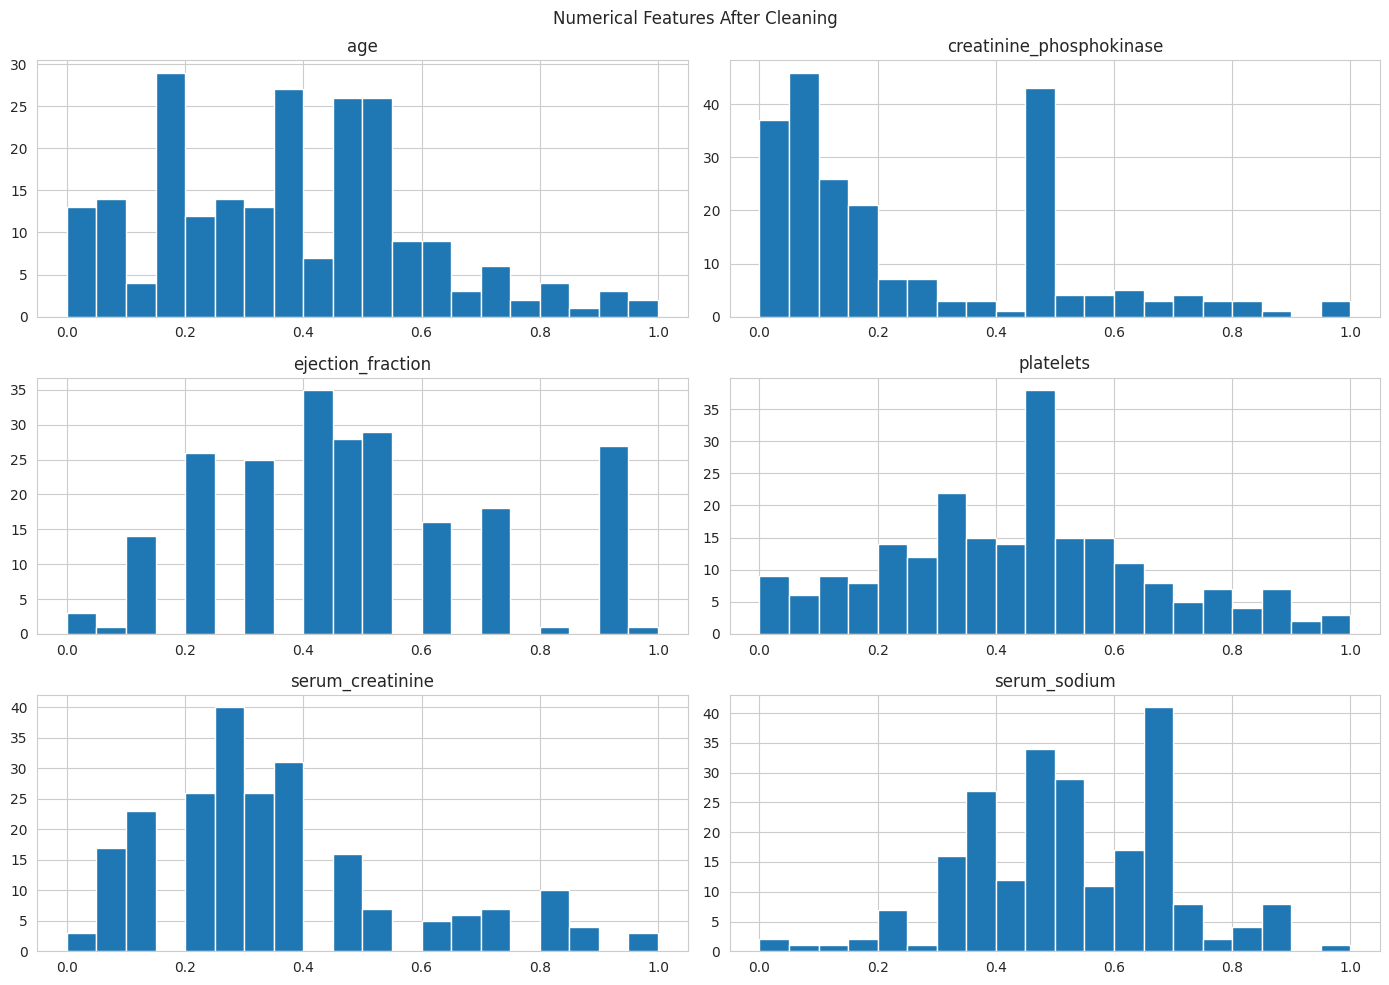

In [30]:
df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Numerical Features After Cleaning")
plt.tight_layout()
plt.show()

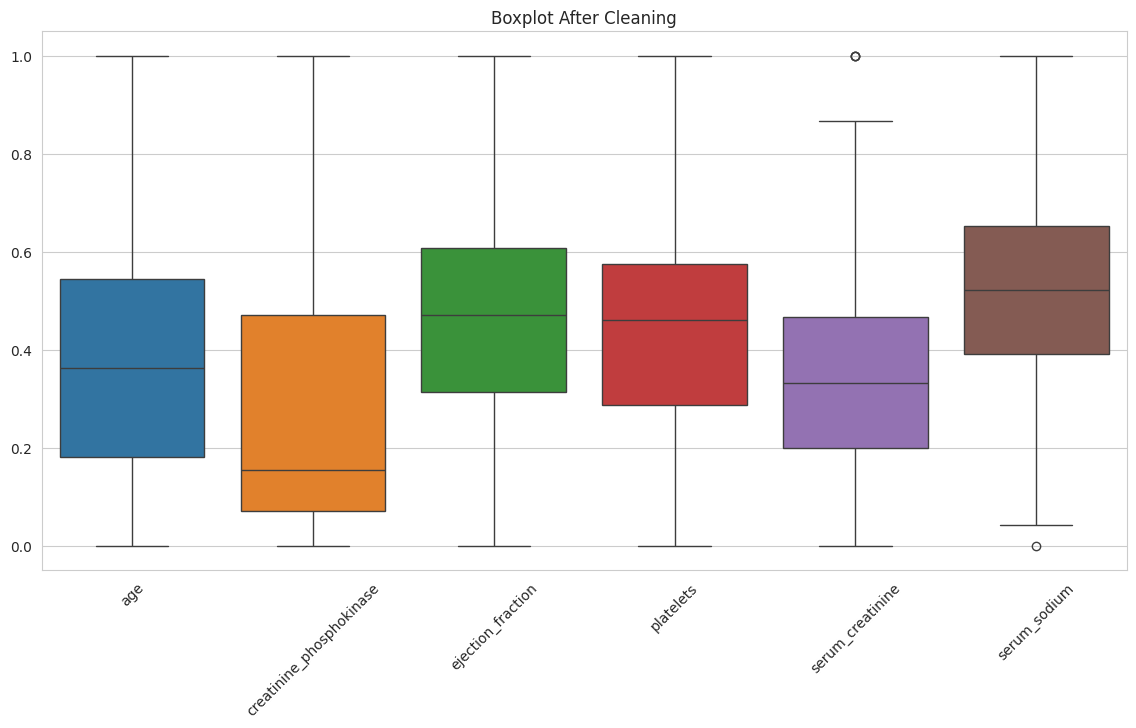

In [31]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=df[numerical_columns])

plt.title("Boxplot After Cleaning")
plt.xticks(rotation=45)
plt.show()

In [32]:
missing_values = df.isnull().sum()

print("Missing values after cleaning:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values remain.")
else:
    print("\nSome missing values still remain.")

Missing values after cleaning:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
ejection_fraction_norm      0
serum_creatinine_norm       0
risk_score                  0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64

No missing values remain.


In [33]:
print("Final dataset shape:", df.shape)

display(df.head())

Final dataset shape: (224, 19)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,ejection_fraction_norm,serum_creatinine_norm,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1,0,4,1,0.117647,0.866667,0.975,0,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1,1,7,1,0.117647,0.466667,0.525,0,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1,0,7,1,0.117647,0.866667,0.975,0,1,0
5,0.909091,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1,1,8,1,0.509804,1.000000,0.625,0,0,1
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1,0,10,1,0.019608,0.400000,0.500,0,0,1


In [34]:
df.to_csv("heart_failure_cleaned.csv", index=False)

print("Cleaned dataset saved as heart_failure_cleaned.csv")

Cleaned dataset saved as heart_failure_cleaned.csv
